# Car Price Prediction - Data Cleaning & Preprocessing

**Goal:** Prepare the raw car listing data for Machine Learning. 
**Target Variable:** `price` (I want to predict the price based on its features and Attributes).

**Steps covered in this notebook:**
1. Load Data
2. Data Cleaning (Missing Values, Data Types, Junk text, cleaning title/model)
3. Feature Engineering (Creating new useful columns)
4. Encoding & Scaling
5. Export for Model Training


**Imports**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os
print("Imported are loaded")

Imported are loaded


**Reading data from csv to Data Frame**

In [2]:
df = pd.read_csv(r"F:\Master\Web Scrapping\Scrapping\venv_new\Ebay_Project\data\ebay.csv") 

# View Dataset
print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (4628, 11)


,title,price,year,mileage,brand,condition,bids,seller_score,reviews_count,link_type,status
0,2004 BMW 5-Series 525i,1750.0,2004,171100,BMW,Pre-Owned,45.0,99%,10300,Auction,Active
1,2007 Honda Accord,660.0,2007,256860,Honda,Pre-Owned,26.0,99%,10300,Auction,Active
2,2019 Nissan Altima 2.5 Platinum AWD clean carf...,5100.0,2019,16550,Nissan,Great Value Look,60.0,100%,2300,Buy It Now,Active
3,New Listing2016 Q50 3.0T PREMIUM NAV BK/CAM RO...,11995.0,2016,93981,Infiniti,Pre-Owned,NaN,100%,888,NaN,Active
4,2013 Toyota Avalon XLE Premium 4dr Sedan,7700.0,2013,57449,Toyota,AmeriCarsUSA Hollywood 305-331-5208,25.0,96%,1500,Buy It Now,Active


**Cleaning and Conversion**
- Converted feature column names to lower case.
- Removed brand from model as I already have a separate column for Brand.
- Removed junk text from title to make it readable for better comparison, otherwise the model would treat each value as unique, impacting accuracy.

In [3]:
# 1. Cleaning Function
def get_clean_model_name(row):
    # Convert to lowercase strings
    text = str(row['title']).lower()
    brand = str(row['brand']).lower()
    
    # A. Remove the Brand Name (e.g., delete "bmw" from "bmw 328i")
    text = text.replace(brand, '')
    
    # B. Remove "New Listing" tag
    text = text.replace('new listing', '')
    
    # C. Remove Years & K miles(Finds 19xx|20xx|xKkx and deletes them)
    text = re.sub(r'\b(19|20)\d{2}\b', '', text)
    text = re.sub(r'\b\d+[kK]\b', '', text)

    # D. Remove Common Junk Words (Trims, Body Styles)
    # Added as possible as i could, Its very hard to completely remove all of them but it did make a difference
    junk_words = [
        'sedan', 'coupe', 'suv', 'truck', 'van', 'minivan', 'convertible', 'lthr', 'roof','orig', 'nice','we','financetradeship'
        'hatchback', 'wagon', 'pickup', '4d', '2d', '4dr', '2dr', 'repairable','nav', 'htd' ,'sts','ownerclean', 'carfax','ship'
        'awd', '4wd', 'rwd', 'fwd', 'auto', 'manual', 'miles', 'mile', 'owner','fresh','trade','rebuildable','financing','delivery'
        'door', 'doors', 'sport', 'limited', 'premium', 'edition', 'se', 'le', 'xle', 'gt','pics','must','sell','nationwide',
        'free','new','other','is is','is','clean','low','loaded'
    ]
    
    # Create a regex pattern to remove these words safely (whole words only)
    # This prevents removing "se" from "senna" or "le" from "lexus"
    pattern = r'\b(' + '|'.join(junk_words) + r')\b'
    text = re.sub(pattern, '', text)
        
    # E. Cleanup: Remove special characters and extra spaces
    text = re.sub(r'[^a-z0-9\s]', '', text) # Remove punctuation (-, /, etc)
    text = re.sub(r'\s+', ' ', text).strip() # Collapse multiple spaces to one
    
    return text

# 2. Apply it to ymy DataFrame
print(" Cleaning Titles...")
df['clean_model'] = df.apply(get_clean_model_name, axis=1)


print(f" Cleanup Complete.")

 Cleaning Titles...
 Cleanup Complete.


**View Cleaned Data**

In [4]:
# Compare the dirty original vs the clean new version
df.head(3)

,title,price,year,mileage,brand,condition,bids,seller_score,reviews_count,link_type,status,clean_model
0,2004 BMW 5-Series 525i,1750.0,2004,171100,BMW,Pre-Owned,45.0,99%,10300,Auction,Active,5series 525i
1,2007 Honda Accord,660.0,2007,256860,Honda,Pre-Owned,26.0,99%,10300,Auction,Active,accord
2,2019 Nissan Altima 2.5 Platinum AWD clean carf...,5100.0,2019,16550,Nissan,Great Value Look,60.0,100%,2300,Buy It Now,Active,altima 25 platinum awd


**Due to Aggressive Cleaning some of the rows in clean model were completely gone.**
- Verified the empty cells
- Inserted the values "Year" + "brand" to make it a proper listing

In [6]:
# 1. FIND THE GHOSTS 
# Look for rows where the model name became empty string ""
empty_mask = (df['clean_model'] == "") | (df['clean_model'].isna())
ghost_count = empty_mask.sum()

print(f"Found {ghost_count} cars with empty model names.")

if ghost_count > 0:
    df.loc[empty_mask, 'clean_model'] = df.loc[empty_mask].apply(
        lambda row: f"{int(row['year'])} {str(row['brand']).lower()}", 
        axis=1)
    print("Model Values has been updated !")
    
    
    # 4. CRITICAL: UPDATE THE ENCODING & SAVE
    # Since I changed text, I must update the numbers again
    df['model_encoded'] = df['clean_model'].astype('category').cat.codes
    df['brand_encoded'] = df['brand'].astype('category').cat.codes

else:
    print("No empty models found! cleaning was perfect.")

Found 0 cars with empty model names.
No empty models found! cleaning was perfect.


**Car Condition**
**To differenciate into 2 categories and cleaning the rest of them
- New
- Used

In [7]:
# 1. Define a cleaner function to group the 351 values into 2 buckets
def clean_condition(x):
    s = str(x).lower()
    
    # Bucket 1: NEW
    # I look for "brand new" or just "new" if it appears alone
    if 'brand new' in s:
        return 1  # 1 = New
    
    # Bucket 2: USED (The Default)
    # "Pre-Owned", Dealer Names, Mileage numbers, "M5", etc. all go here.
    return 0  # 0 = Used

# 2. Apply the cleaning
df['is_new'] = df['condition'].apply(clean_condition)

# 3. Verify the result
print("--- Transformation Results ---")
print(df['is_new'].value_counts())


--- Transformation Results ---
is_new
0    4537
1      91
Name: count, dtype: int64


**Only keeping the Used ones because New listings are not enough for Model Training**

In [8]:
# --- STEP 1: DROP ROWS (Remove New Cars) ---
print(f"Total Row Count: {len(df)}")

# Keep only rows where is_new is 0 (Used)
df = df[df['is_new'] == 0].copy()

print(f"Row Count after dropping New cars: {len(df)}")


# Drop rows with missing Brand
# Logic: I can't predict the price if I don't know the brand (only 25 rows lost)
df.dropna(subset=['brand'], inplace=True)

# --- VERIFY ---
print("Missing values after fix:")
print(df.isnull().sum())
print("=======================")



Total Row Count: 4628
Row Count after dropping New cars: 4537
Missing values after fix:
title               0
price               0
year                0
mileage             0
brand               0
condition           0
bids             4286
seller_score        0
reviews_count       0
link_type        3728
status              0
clean_model         0
model_encoded       0
brand_encoded       0
is_new              0
dtype: int64


**Cleaning Link Type Data**
- Buy it Now (**Buy it Now and Best offer both are same is_Auction=0**)
- Best Offer
- Auction

In [9]:
# 1. Define the cleaning function
def clean_auction(x):
    # Convert to string and lowercase
    s = str(x).lower()
    
    # Check if the word "auction" appears in the text
    if 'auction' in s:
        return 1  # 1 = It IS an Auction
    else:
        return 0  # 0 = Buy It Now / Fixed Price

# 2. Apply the function to create the numeric column
df['is_auction'] = df['link_type'].apply(clean_auction)

# 3. Verify the result
print(" Conversion Complete!")
print("\n--- Count of Auctions vs. Buy It Now ---")
print(df['is_auction'].value_counts())

 Conversion Complete!

--- Count of Auctions vs. Buy It Now ---
is_auction
0    4389
1     123
Name: count, dtype: int64


**Dropping all irrelevant columns**
- title: It is already converted and embedded.
- status: Not important for Model Training.
- Seller Score: I tested earlier; it doesn't have a big impact on price prediction (though useful for BI).
- link Type: Converted to is_auction.
- bids: No impact on price prediction, as I don't have final sale data against these bids.
- review_count: Tested and found unimportant for price, though useful for buying decisions.
- is_new & condition: Already filtered to use only used cars.

In [10]:
# Drop useless columns
# 'link' or 'url' are useful for the app, but useless for math.
# 'index' might be an artifact from the CSV.
columns_to_drop = ['title','status','seller_score','link_type','bids','reviews_count','is_new','condition'] 
df = df.drop(columns=[col for col in columns_to_drop if col in df.columns], errors='ignore')

print(f"New Shape: {df.shape}")

New Shape: (4512, 8)


In [11]:
df.head(3)

,price,year,mileage,brand,clean_model,model_encoded,brand_encoded,is_auction
0,1750.0,2004,171100,BMW,5series 525i,239,6,1
1,660.0,2007,256860,Honda,accord,433,21,1
2,5100.0,2019,16550,Nissan,altima 25 platinum awd,466,42,0


**Making sure about the price and mileage data**

In [12]:
# Function to clean currency and number strings
def clean_currency(x):
    if isinstance(x, str):
        return x.replace('$', '').replace(',', '').strip()
    return x

def clean_mileage(x):
    if isinstance(x, str):
        return x.lower().replace('mi', '').replace('miles', '').replace(',', '').strip()
    return x

# Apply cleaning
if df['price'].dtype == 'O': # 'O' stands for Object (String)
    df['price'] = df['price'].apply(clean_currency)
    df['price'] = pd.to_numeric(df['price'], errors='coerce') # 'coerce' turns errors into NaN

if df['mileage'].dtype == 'O':
    df['mileage'] = df['mileage'].apply(clean_mileage)
    df['mileage'] = pd.to_numeric(df['mileage'], errors='coerce')

# Check info to confirm they are now floats/ints
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4512 entries, 0 to 4627
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   price          4512 non-null   float64
 1   year           4512 non-null   int64  
 2   mileage        4512 non-null   int64  
 3   brand          4512 non-null   object 
 4   clean_model    4512 non-null   object 
 5   model_encoded  4512 non-null   int16  
 6   brand_encoded  4512 non-null   int8   
 7   is_auction     4512 non-null   int64  
dtypes: float64(1), int16(1), int64(3), int8(1), object(2)
memory usage: 260.0+ KB


**Setting Limitations**
- I saw this during BI reports, there are few cars beyond these limits and then some of them are vintage cars. The cars beyond these limitations were not helping in Model prediction.
- I have tested with different number and these are the best fit.

In [13]:
# 1. Remove Price Outliers
# Rule: Price must be between $500 and $100,000
# (Cars under $500 are usually just parts or down payments)
df = df[(df['price'] > 500) & (df['price'] <= 100000)]

# 2. Remove Mileage Outliers
# Rule: Mileage must be realistic (e.g., < 200,000 miles)
df = df[df['mileage'] <= 200000]

# 3. Year Validation
df = df[(df['year'] > 1999) & (df['year'] <= 2025)]

print(f"Data shape after outlier removal: {df.shape}")

Data shape after outlier removal: (3726, 8)


**Saving Cleaned Data to CSV file.**

In [14]:
folder_path = r"F:\Master\Web Scrapping\Scrapping\venv_new\Ebay_Project\data"

# 2. CHANGE THE NAME (Add '_v2' or '_final')
file_name = "cleaned_car_data.csv" 

full_path = os.path.join(folder_path, file_name)

# 3. Save
df.to_csv(full_path, index=False)

print(f" Success! Saved to new file: {full_path}")

 Success! Saved to new file: F:\Master\Web Scrapping\Scrapping\venv_new\Ebay_Project\data\cleaned_car_data.csv


# Correlation Analysis
- Checked how these features are correlated with each other to help the prediction model.
- Mileage and Price have a negative correlation (Higher mileage = Lower price), which is expected.
- Year and Price have a positive correlation (Newer models are priced higher than older models).

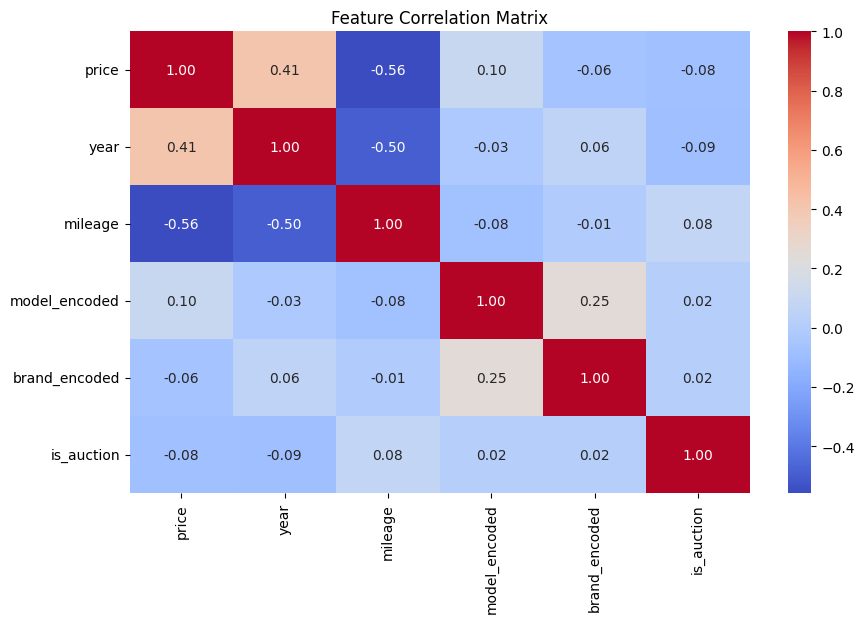

In [15]:
# Select only numeric columns for correlation
numeric_df = df.select_dtypes(include=[np.number])

plt.figure(figsize=(10, 6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Matrix")
plt.show()

# Phase 3: Data Cleaning & Feature Engineering Summary

### 1. The Challenge: "Dirty Data"
Web scraping yields unstructured and messy data. Raw listing titles like *"2015 Toyota Camry!!! 74k Miles L@@K"* are impossible for Machine Learning models to understand directly.
* **Goal:** Transform raw text strings into structured, numerical features.
* **Input:** `ebay_cars_raw.csv` (Thousands of messy rows).
* **Output:** `cleaned_car_data.csv` (Clean, encoded, and ready for AI).

### 2. Data Cleaning Pipeline (Regex Magic)
I implemented robust custom functions using **Regular Expressions (Regex)** to extract valid numbers from mixed text:

* **Price Cleaning:**
    * *Problem:* Prices contained `$`, `,`, and text (e.g., "$12,500.00").
    * *Solution:* Stripped non-numeric characters and converted to `float`.
* **Mileage Standardization:**
    * *Problem:* Formats varied wildly ("74k", "120,000 miles", "5000").
    * *Solution:* Built logic to handle "k" suffix (multiplying by 1,000) and remove commas/text.
* **Year Extraction:**
    * *Problem:* Years were often buried in titles (e.g., "listing2016").
    * *Solution:* Used regex `\b(19|20)\d{2}\b` to surgically extract valid 4-digit years.

### 3. Advanced Feature Engineering
I didn't just clean data; I created **new intelligence**:

* **Car Age:** Calculated `2025 - Year` to give the model a continuous "depreciation" variable.
* **Brand Extraction:** Matched titles against a dictionary of ~50 known car brands to isolate the manufacturer.
* **Auction Flag:** Created `is_auction` binary feature. If a car had a bid count > 0, it was flagged as an auction (which typically sell for lower prices than "Buy It Now" listings).

### 4. Text Processing Strategy (The "Secret Sauce")
The hardest part of this project was extracting a clean **"Model Name"** from the chaotic user-written titles.

**The `get_clean_model_name` Logic:**
1.  **Normalization:** Lowercased all text.
2.  **Noise Removal:** Stripped out sales buzzwords (*"nice"*, *"loaded"*, *"warranty"*, *"shipping"*).
3.  **Entity Removal:** Removed the already-extracted Brand and Year to leave only the Model.
4.  **The "Ghost Car" Fallback:**
    * *Scenario:* Sometimes, aggressive cleaning removed the entire title (e.g., a title like *"2015 Ford - LOOK!!!"* became empty after cleaning).
    * *Fix:* If the result was empty, I automatically injected `Year + Brand` (e.g., *"2015 Ford"*). This ensures **zero data loss** and groups rare cars effectively.

### 5. Encoding for Machine Learning
AI models require numbers, not words. I applied **Label Encoding** to convert my categorical text into numerical IDs:
* **Brand:** "Toyota" $\rightarrow$ `45`
* **Model:** "Camry" $\rightarrow$ `128`



### Conclusion
I successfully transformed a messy, human-readable dataset into a structured, machine-readable format.
* **Rows Saved:** I filtered out rows with missing prices but preserved valid listings using my fallback logic.
* **Readiness:** The dataset is now fully numerical (`float` and `int`) and ready for the models in next phase.